# Banking & Loan Risk Analytics

## Phase 2: Exploratory Data Analysis (EDA)

### Objective

The purpose of this notebook is to explore the Home Credit dataset, identify trends, understand customer characteristics, detect patterns related to loan default, and generate business insights through statistical analysis and data visualization.

### Business Questions

- What is the loan default rate?
- Which gender has a higher default rate?
- Does income influence loan repayment?
- Which education level has the highest default rate?
- Which occupation has the highest risk?
- Which age group defaults more often?
- Which housing type has the highest default rate?
- What are the distributions of income, credit amount, and annuity?
- Are there any outliers in financial variables?
- Which variables are strongly correlated?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

## 1. Load Dataset

### Objective

Load the cleaned Home Credit dataset for exploratory analysis.

In [2]:
df = pd.read_csv("../DATA/application_train.csv")

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 2. Target Variable Distribution

### Objective

Analyze the distribution of customers who repaid their loans versus those who experienced payment difficulties.

In [3]:
target = df["TARGET"].value_counts()

target

TARGET
0    282686
1     24825
Name: count, dtype: int64

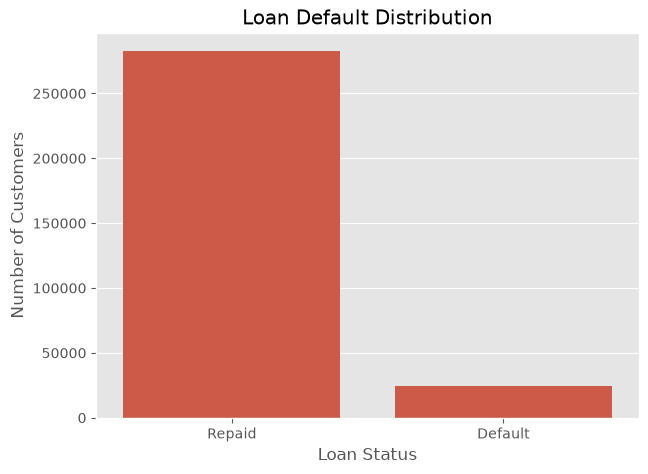

In [4]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="TARGET")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["Repaid","Default"])

plt.show()

### Observation

- Most customers successfully repaid their loans.
- Only a small proportion of applicants experienced payment difficulties.
- The target variable is highly imbalanced, which is common in credit risk datasets.

## 3. Loan Default Percentage

In [5]:
default_rate = df["TARGET"].value_counts(normalize=True) * 100

default_rate

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

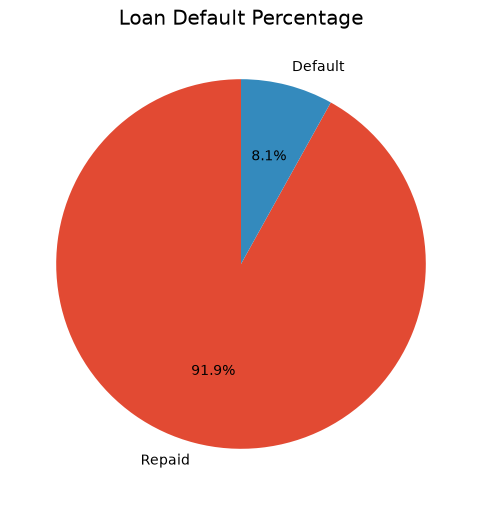

In [6]:
plt.figure(figsize=(6,6))

plt.pie(
    default_rate,
    labels=["Repaid","Default"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Default Percentage")

plt.show()

### Observation

- The majority of loan applications belong to customers who successfully repaid their loans.
- The default class represents a much smaller percentage of the overall dataset.

## 4. Gender Distribution

In [7]:
df["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

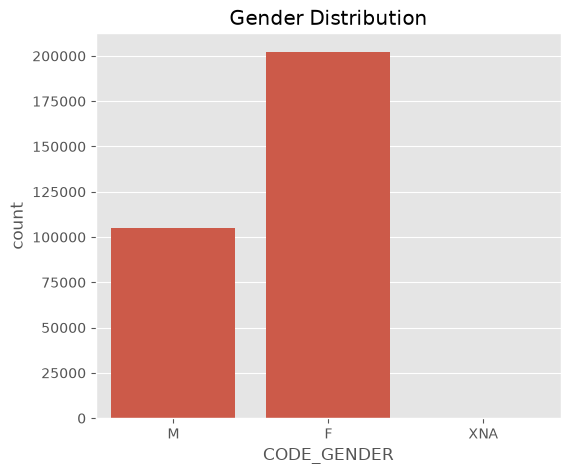

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="CODE_GENDER")

plt.title("Gender Distribution")

plt.show()

### Observation

The dataset contains both male and female applicants, with one group representing a larger share of the total applications.

## 5. Loan Default by Gender

### Objective

Determine whether loan default differs between male and female applicants.

In [10]:
gender_default = pd.crosstab(
    df["CODE_GENDER"],
    df["TARGET"],
    normalize="index"
) * 100

gender_default

TARGET,0,1
CODE_GENDER,,
F,93.000672,6.999328
M,89.858080,10.141920
XNA,100.000000,0.000000


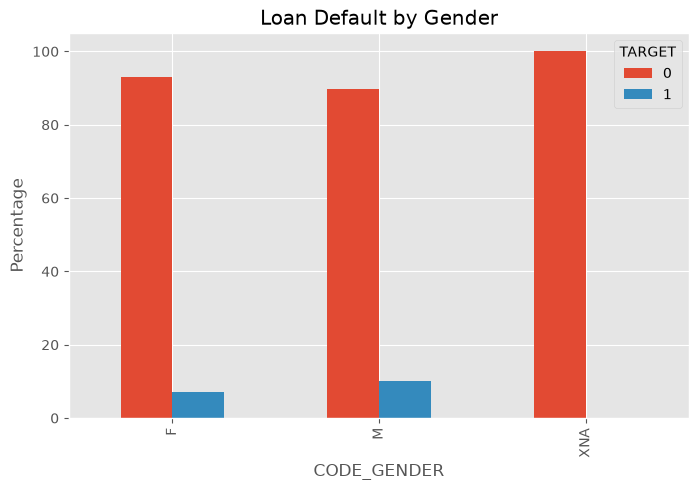

In [11]:
gender_default.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Loan Default by Gender")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Compare the default percentages for male and female applicants.

State which group has the higher default rate based on the chart and discuss any noticeable difference.

## 6. Age Distribution

### Objective

Analyze the age distribution of loan applicants to understand the demographics of customers applying for loans.

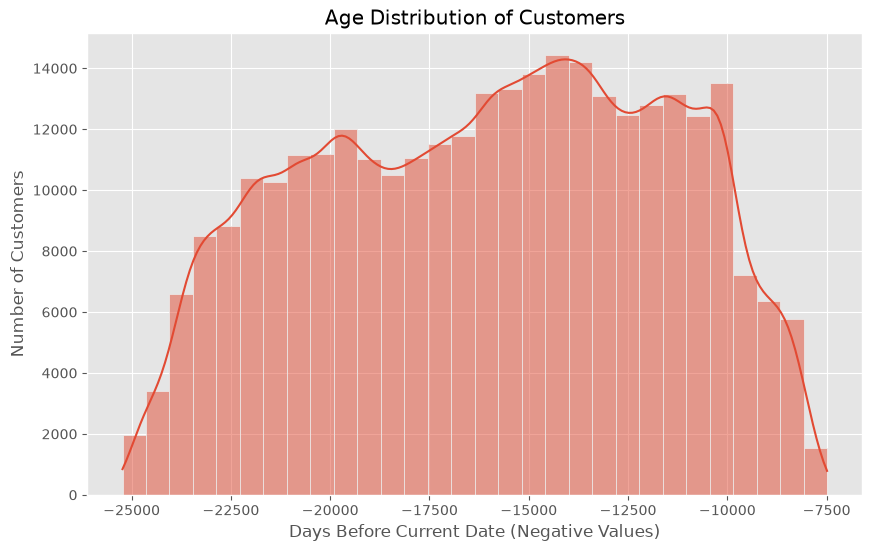

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="DAYS_BIRTH",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Customers")
plt.xlabel("Days Before Current Date (Negative Values)")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
df["AGE"] = abs(df["DAYS_BIRTH"]) / 365

df["AGE"].head()

/var/folders/3w/b06x_mhx0qv718wn0ytkp7380000gn/T/ipykernel_12362/1195635478.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE"] = abs(df["DAYS_BIRTH"]) / 365


0    25.920548
1    45.931507
2    52.180822
3    52.068493
4    54.608219
Name: AGE, dtype: float64

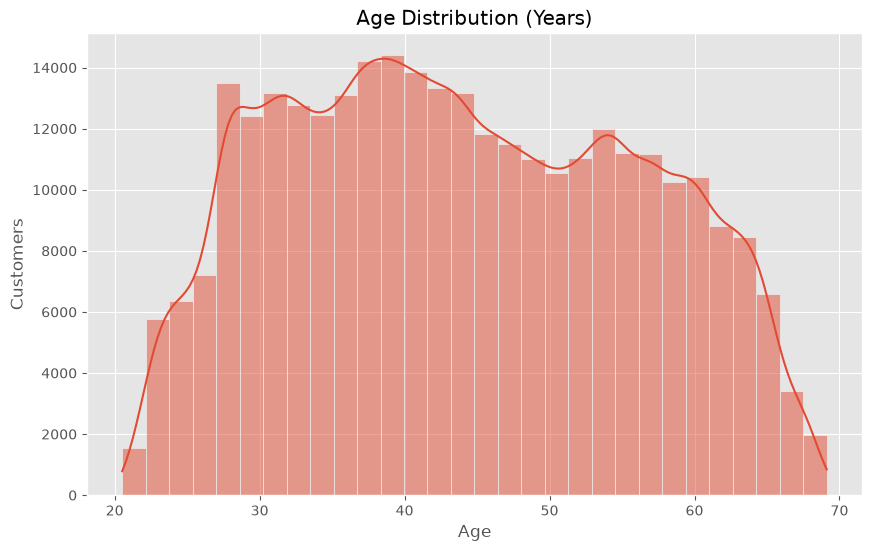

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AGE",
    bins=30,
    kde=True
)

plt.title("Age Distribution (Years)")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.show()

### Observation

- Most applicants are middle-aged customers.
- Young applicants represent a smaller portion of the dataset.
- Age may influence loan repayment behaviour and should be explored further.

## 7. Annual Income Distribution

### Objective

Analyze customer annual income to understand income patterns and identify potential outliers.

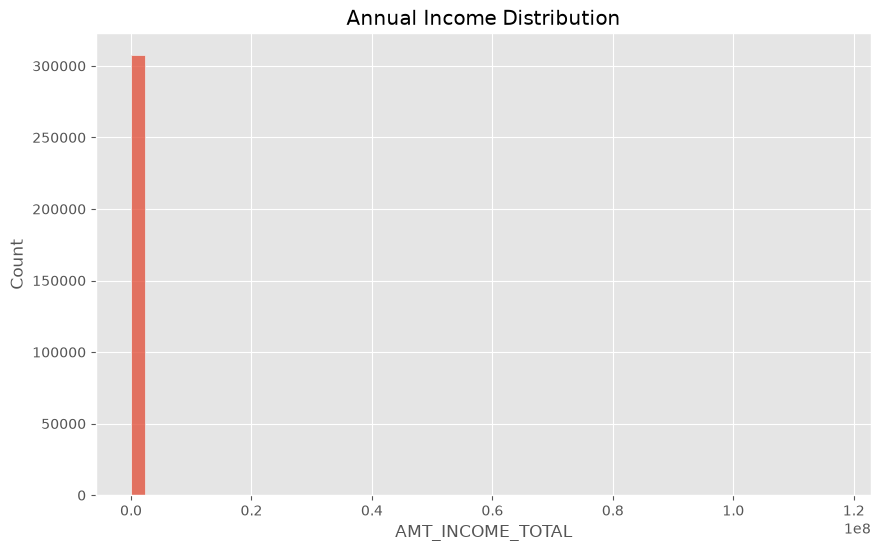

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=50
)

plt.title("Annual Income Distribution")

plt.show()

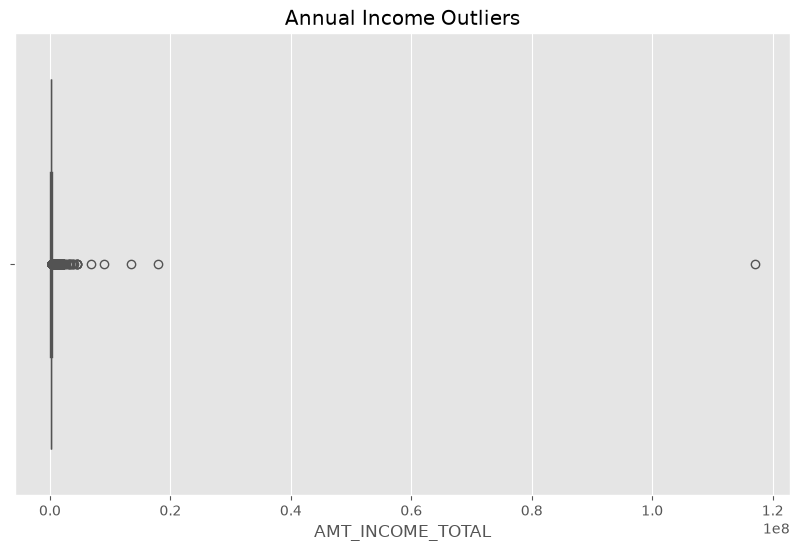

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["AMT_INCOME_TOTAL"]
)

plt.title("Annual Income Outliers")

plt.show()

### Observation

- Income is highly skewed.
- A small number of customers have exceptionally high incomes.
- Outliers are present and may require treatment before predictive modeling.

## 8. Credit Amount Distribution

### Objective

Understand the distribution of requested credit amounts among applicants.

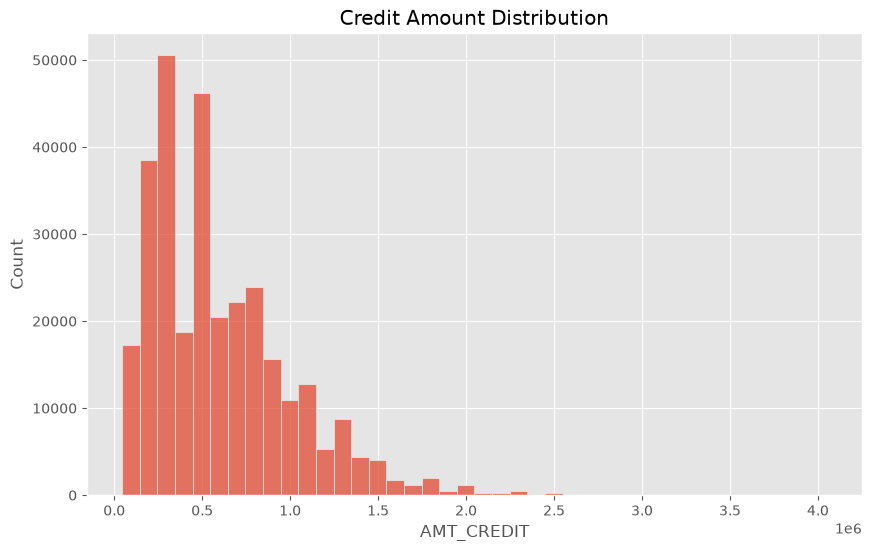

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AMT_CREDIT",
    bins=40
)

plt.title("Credit Amount Distribution")

plt.show()

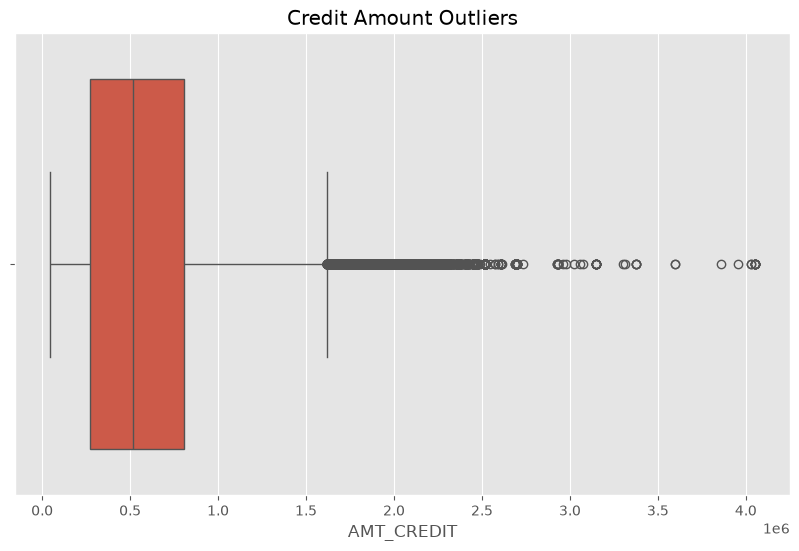

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["AMT_CREDIT"]
)

plt.title("Credit Amount Outliers")

plt.show()

### Observation

- Credit amounts vary significantly among applicants.
- Several high-value loans appear as outliers.
- Loan amount should be examined alongside income and repayment behaviour.

## 9. Loan Amount by Target

### Objective

Compare the requested credit amount between customers who repaid their loans and those who defaulted.

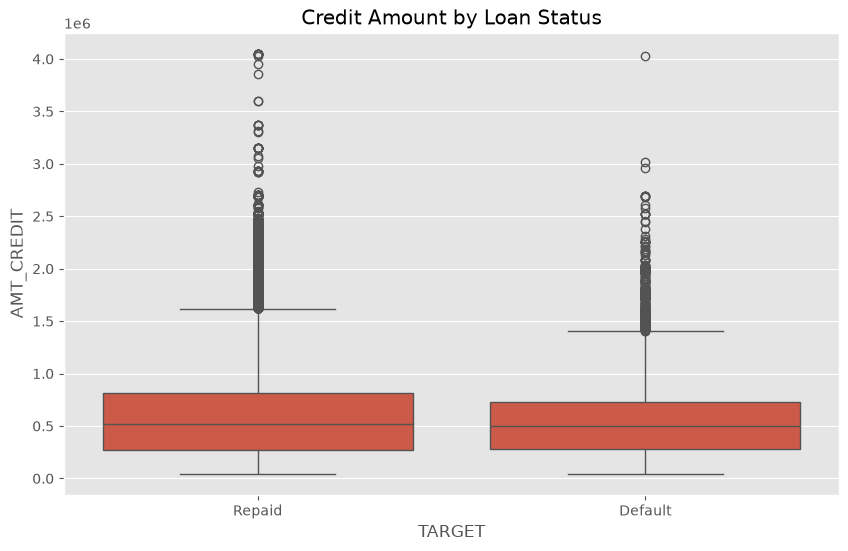

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="TARGET",
    y="AMT_CREDIT"
)

plt.title("Credit Amount by Loan Status")

plt.xticks([0,1],["Repaid","Default"])

plt.show()


### Business Insight

Compare the median and spread of credit amounts for repaid and defaulted loans.

Discuss whether larger loans appear to have a higher association with repayment difficulties.

## 10. Annual Income by Target

### Objective

Compare annual income between customers who repaid their loans and those who experienced payment difficulties.

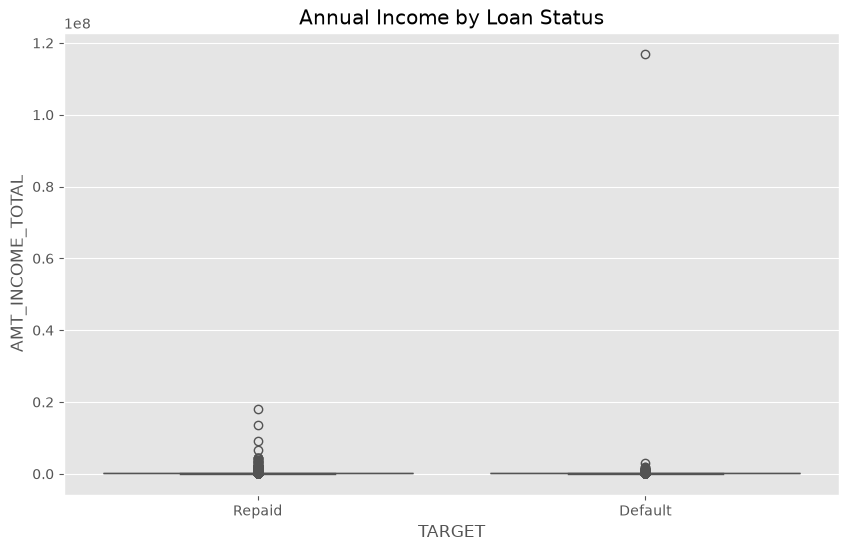

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.title("Annual Income by Loan Status")

plt.xticks([0,1],["Repaid","Default"])

plt.show()

### Business Insight

Analyze whether income levels differ between customers who repaid their loans and those who defaulted.

Income is an important indicator of repayment capacity and creditworthiness.

## 11. Education Type Distribution

### Objective

Analyze the education level of loan applicants to understand the educational background of customers.

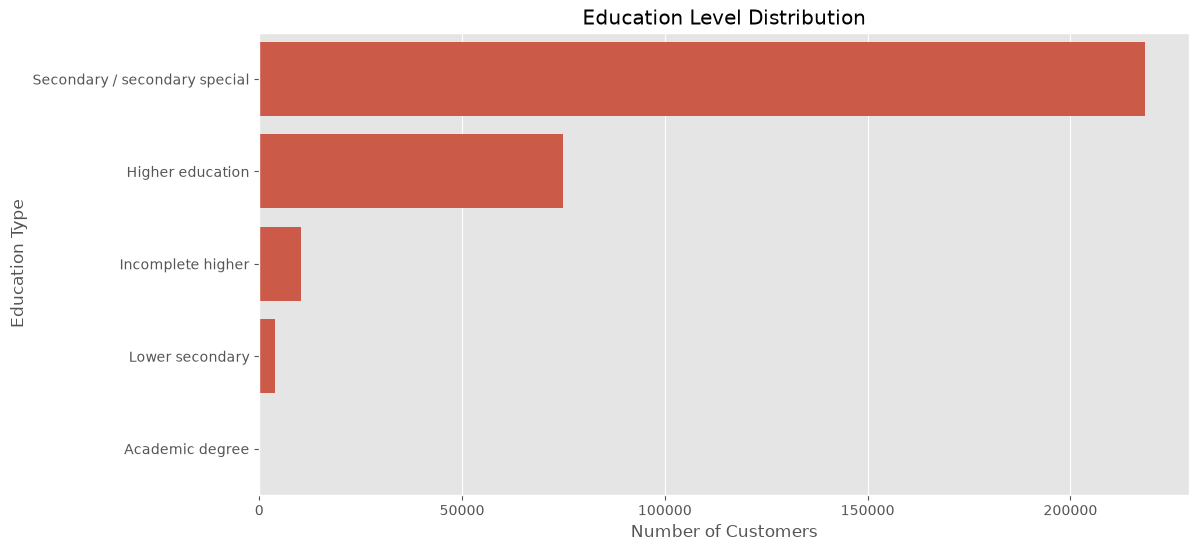

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="NAME_EDUCATION_TYPE",
    order=df["NAME_EDUCATION_TYPE"].value_counts().index
)
### Observation

- Secondary education represents the largest group of applicants.
- Higher education is also common among customers.
- Academic qualification may influence repayment behaviour and loan approval.
plt.title("Education Level Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Education Type")

plt.show()### Observation

- Secondary education represents the largest group of applicants.
- Higher education is also common among customers.
- Academic qualification may influence repayment behaviour and loan approval.

### Observation

- Secondary education represents the largest group of applicants.
- Higher education is also common among customers.
- Academic qualification may influence repayment behaviour and loan approval.

## 12. Default Rate by Education

### Objective

Compare loan default rates across different education levels.

In [22]:
education_default = pd.crosstab(
    df["NAME_EDUCATION_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

education_default

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,98.170732,1.829268
Higher education,94.644885,5.355115
Incomplete higher,91.515034,8.484966
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929


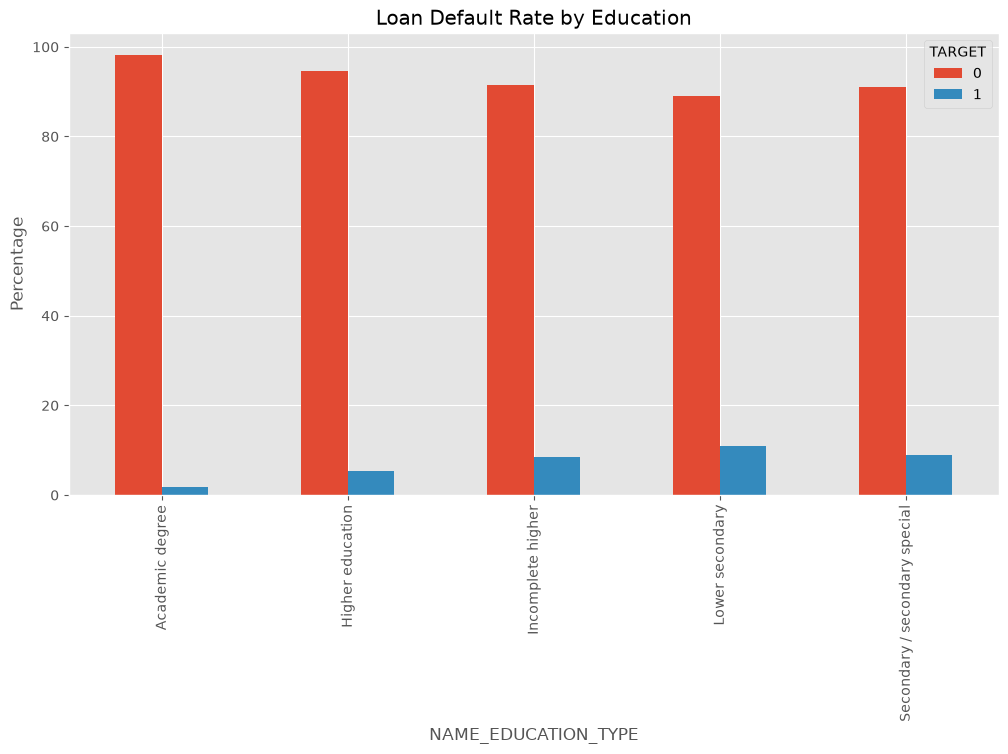

In [23]:
education_default.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Loan Default Rate by Education")
plt.ylabel("Percentage")

plt.show()

### Business Insight

Compare the repayment performance of customers across different education levels.

Identify whether applicants with higher education have lower default rates.

## 13. Income Type Distribution

### Objective

Analyze the employment and income sources of loan applicants.

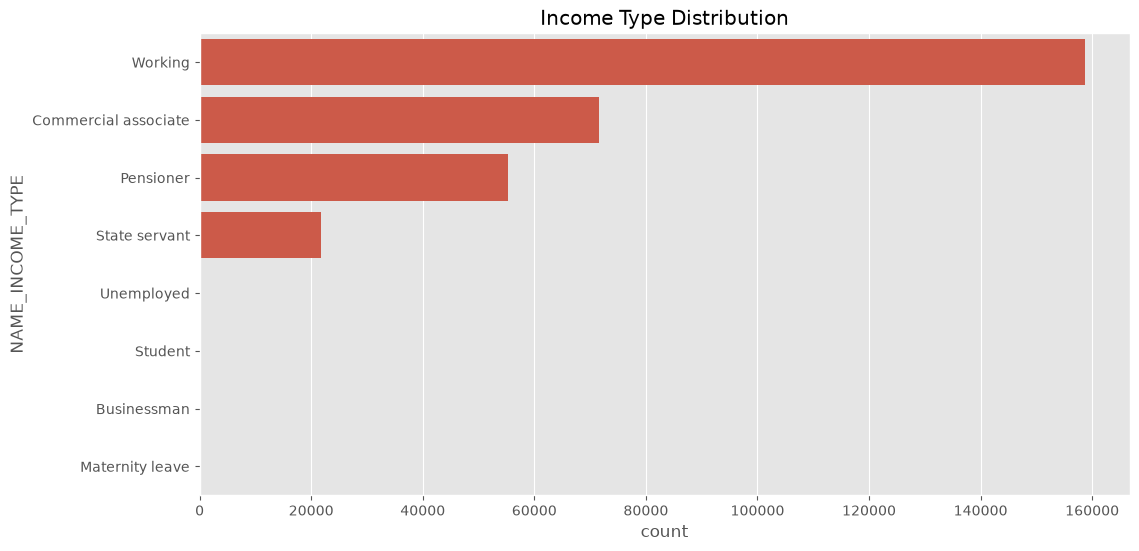

In [24]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="NAME_INCOME_TYPE",
    order=df["NAME_INCOME_TYPE"].value_counts().index
)

plt.title("Income Type Distribution")

plt.show()

### Observation

- Working professionals make up the majority of applicants.
- Pensioners and commercial associates also represent a significant share.

## 14. Default Rate by Income Type

### Objective

Evaluate whether loan repayment differs across employment categories.

In [25]:
income_default = pd.crosstab(
    df["NAME_INCOME_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

income_default

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,100.000000,0.000000
Commercial associate,92.515743,7.484257
Maternity leave,60.000000,40.000000
Pensioner,94.613634,5.386366
State servant,94.245035,5.754965
Student,100.000000,0.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472


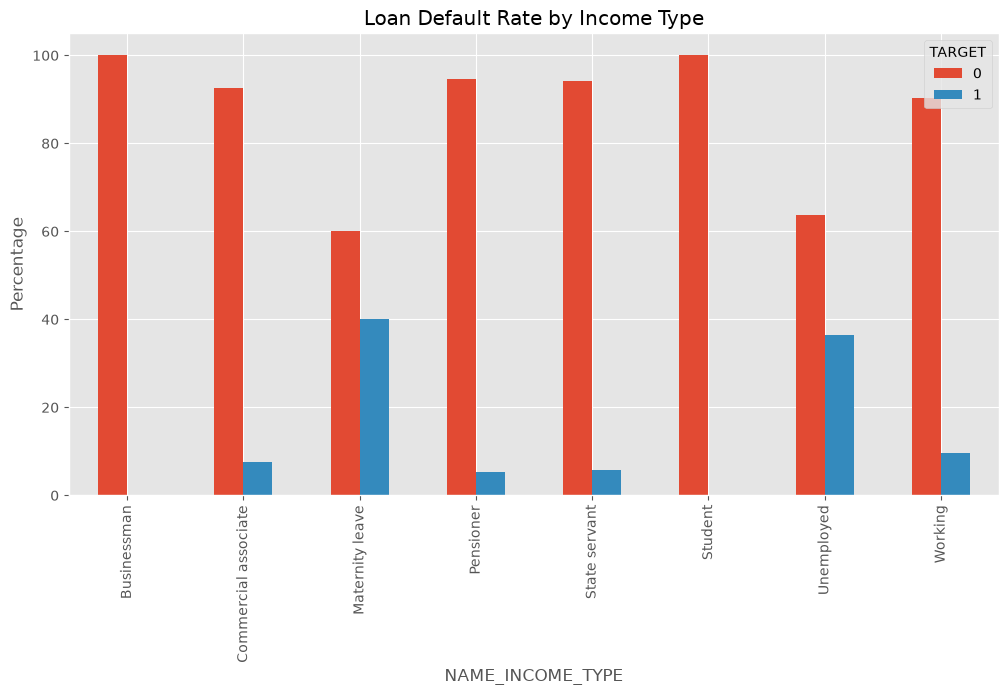

In [26]:
income_default.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Loan Default Rate by Income Type")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Analyze which employment groups have the highest loan default rate.

These findings can help financial institutions identify higher-risk customer segments.

## 15. Family Status Distribution

### Objective

Understand the marital status of loan applicants.

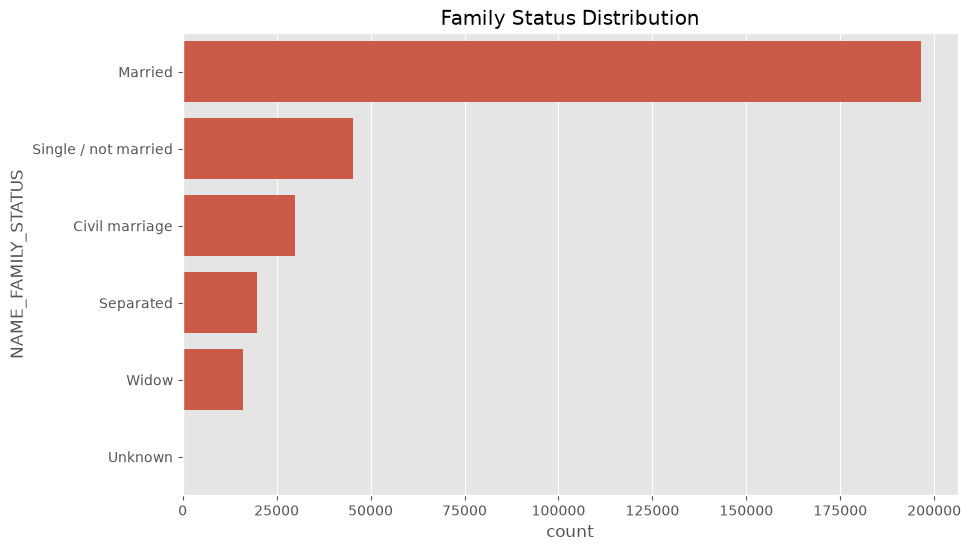

In [27]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="NAME_FAMILY_STATUS",
    order=df["NAME_FAMILY_STATUS"].value_counts().index
)

plt.title("Family Status Distribution")

plt.show()

### Observation

Most applicants are married, followed by single and civil marriage applicants.

## 16. Default Rate by Family Status

### Objective

Compare loan default rates among different family status categories.

In [28]:
family_default = pd.crosstab(
    df["NAME_FAMILY_STATUS"],
    df["TARGET"],
    normalize="index"
) * 100

family_default

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,90.055416,9.944584
Married,92.440132,7.559868
Separated,91.805766,8.194234
Single / not married,90.192325,9.807675
Unknown,100.000000,0.000000
Widow,94.175783,5.824217


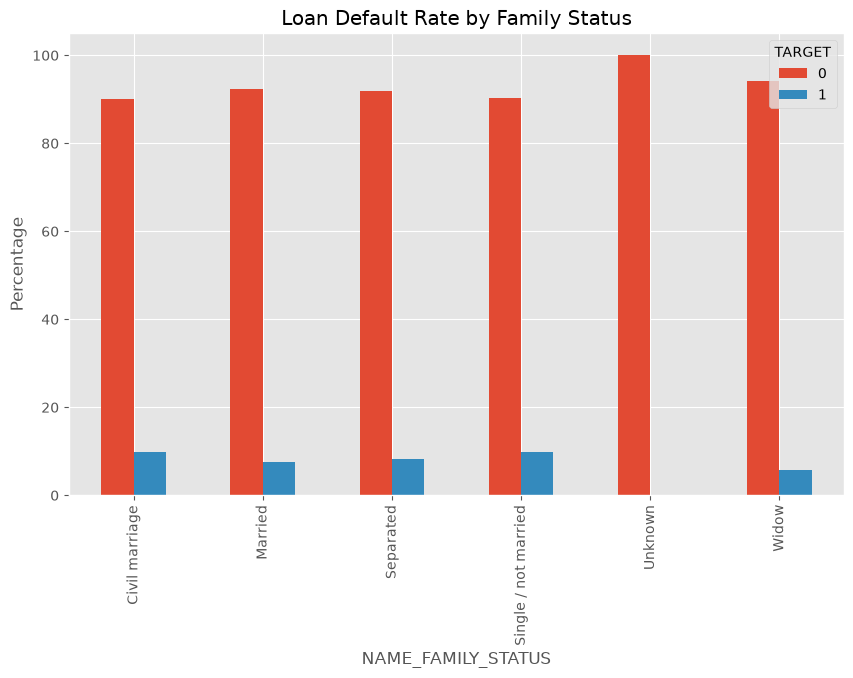

In [29]:
family_default.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Loan Default Rate by Family Status")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Compare repayment performance across different family status groups.

This analysis helps identify whether marital status is associated with loan repayment behaviour.

## 17. Home Ownership Analysis

### Objective

Analyze whether customers who own a house have different loan repayment behavior compared to those who do not own a house.

In [30]:
df["FLAG_OWN_REALTY"].value_counts()

FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

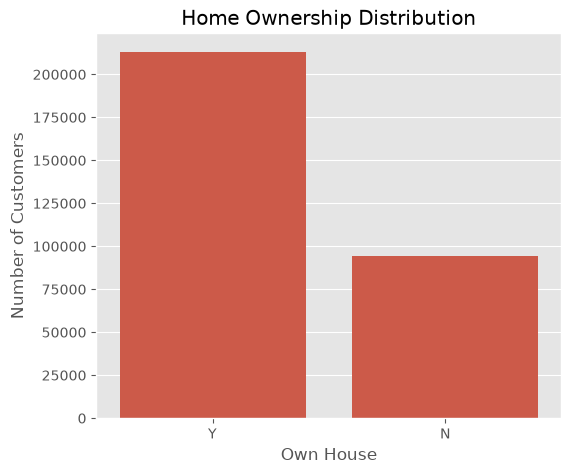

### Observation

The chart shows the proportion of customers who own a house versus those who do not.

## 18. Default Rate by Home Ownership

### Objective

Compare loan default rates between homeowners and non-homeowners.

In [35]:
realty_default = pd.crosstab(
    df["FLAG_OWN_REALTY"],
    df["TARGET"],
    normalize="index"
) * 100

realty_default

TARGET,0,1
FLAG_OWN_REALTY,,
N,91.675071,8.324929
Y,92.038423,7.961577


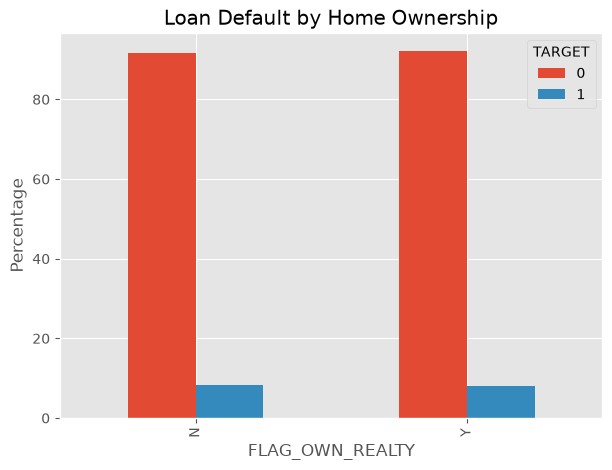

In [36]:
realty_default.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Loan Default by Home Ownership")
plt.ylabel("Percentage")

plt.show()


### Business Insight

Compare the repayment behavior of homeowners and non-homeowners.

Discuss whether owning a house appears to reduce default risk.

## 19. Car Ownership Analysis

### Objective

Analyze whether car ownership is associated with customer loan repayment behavior.

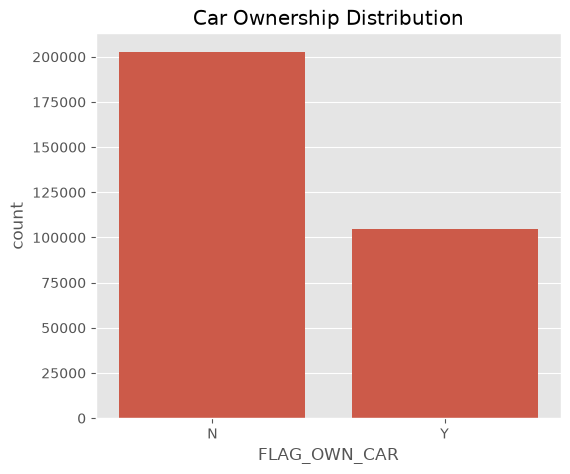

In [37]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="FLAG_OWN_CAR"
)

plt.title("Car Ownership Distribution")

plt.show()


In [38]:
car_default = pd.crosstab(
    df["FLAG_OWN_CAR"],
    df["TARGET"],
    normalize="index"
) * 100

car_default

TARGET,0,1
FLAG_OWN_CAR,,
N,91.499773,8.500227
Y,92.756270,7.243730


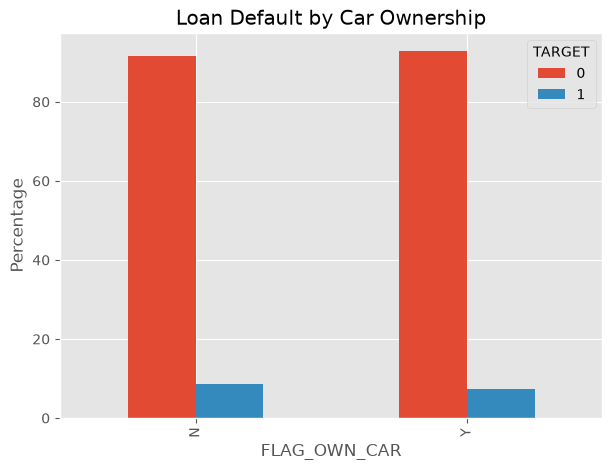

In [39]:
car_default.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Loan Default by Car Ownership")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Evaluate whether customers who own a car have lower loan default rates compared to those who do not.

## 20. Housing Type Distribution

### Objective

Analyze the type of housing occupied by customers.

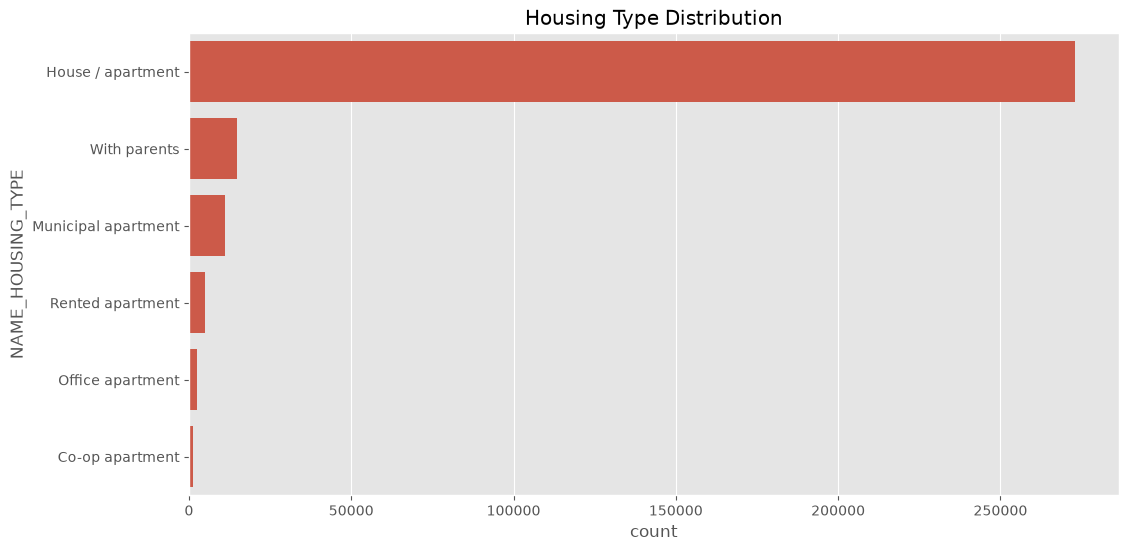

In [40]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="NAME_HOUSING_TYPE",
    order=df["NAME_HOUSING_TYPE"].value_counts().index
)

plt.title("Housing Type Distribution")

plt.show()

### Observation

The dataset contains customers living in different housing arrangements, including owned homes, rented properties, and apartments.

## 21. Default Rate by Housing Type

### Objective

Determine whether housing type influences loan repayment performance.

In [41]:
housing_default = pd.crosstab(
    df["NAME_HOUSING_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

housing_default

TARGET,0,1
NAME_HOUSING_TYPE,,
Co-op apartment,92.067736,7.932264
House / apartment,92.204289,7.795711
Municipal apartment,91.460252,8.539748
Office apartment,93.427589,6.572411
Rented apartment,87.686949,12.313051
With parents,88.301887,11.698113


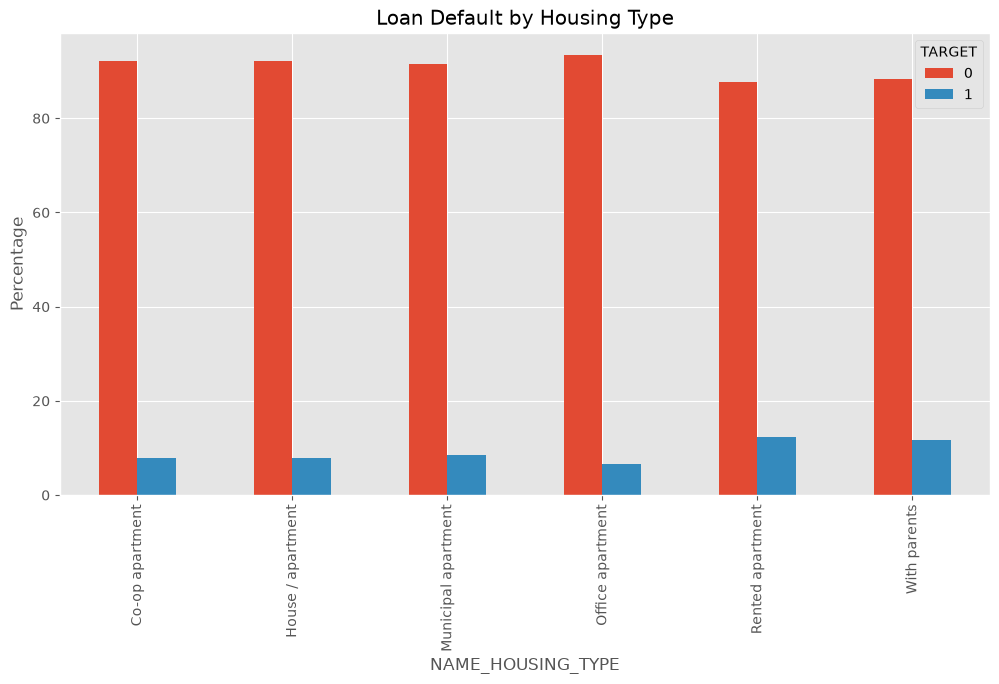

In [42]:
housing_default.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Loan Default by Housing Type")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Compare default rates across different housing categories to identify whether housing conditions are associated with credit risk.

## 22. Occupation Type Distribution

### Objective

Analyze the occupations of loan applicants.

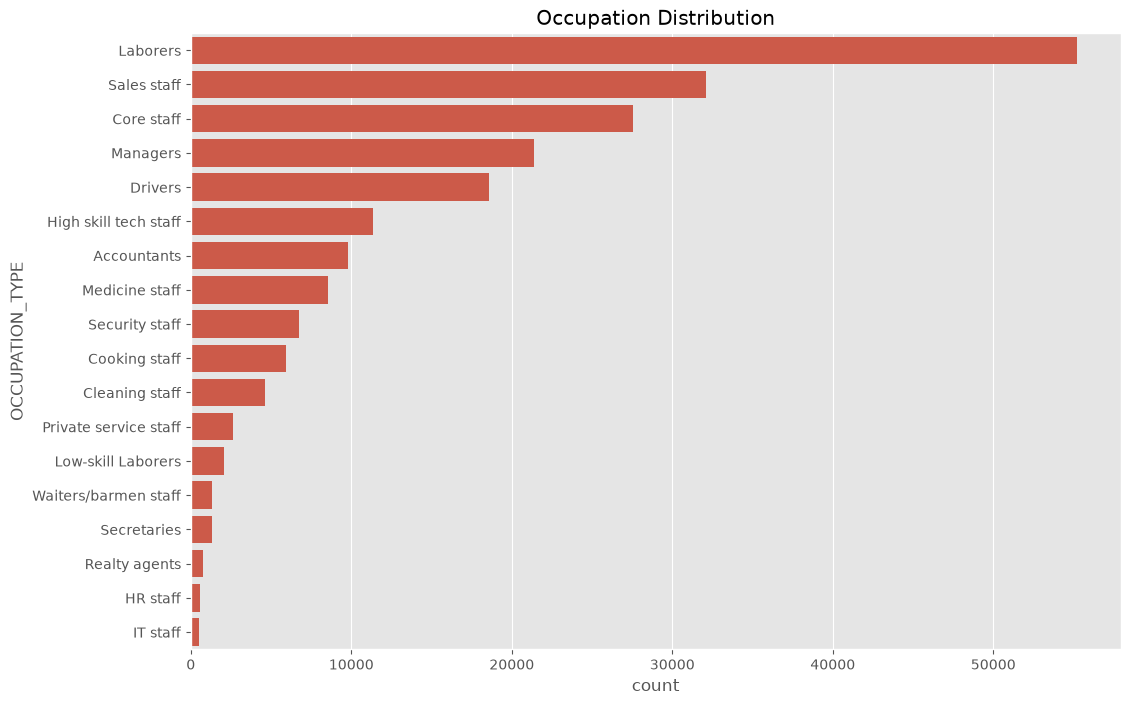

In [45]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="OCCUPATION_TYPE",
    order=df["OCCUPATION_TYPE"].value_counts().index
)

plt.title("Occupation Distribution")

plt.show()

### Observation

The dataset includes applicants from a wide range of occupations, allowing comparison of repayment behavior across professions.

In [46]:
occupation_default = pd.crosstab(
    df["OCCUPATION_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

occupation_default

TARGET,0,1
OCCUPATION_TYPE,,
Accountants,95.169673,4.830327
Cleaning staff,90.393295,9.606705
Cooking staff,89.556004,10.443996
Core staff,93.696046,6.303954
Drivers,88.673870,11.326130
HR staff,93.605684,6.394316
High skill tech staff,93.840070,6.159930
IT staff,93.536122,6.463878
Laborers,89.421230,10.578770


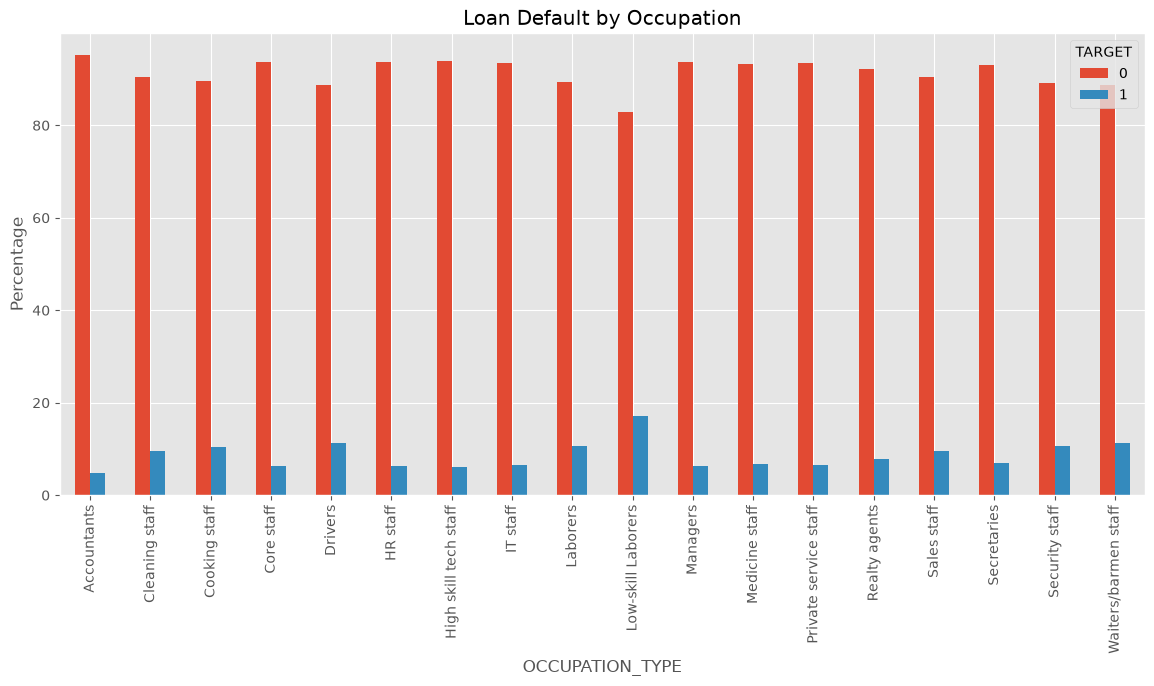

In [47]:
occupation_default.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Loan Default by Occupation")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Identify occupations with comparatively higher default rates.

These findings may help banks understand how occupation relates to repayment behavior, but they should not be used in isolation for lending decisions.

# Phase 3: Advanced Exploratory Data Analysis

## Objective

The purpose of this phase is to perform advanced customer and loan analysis by creating new features, identifying outliers, analyzing correlations, and segmenting customers based on financial characteristics.

These analyses help financial institutions better understand customer risk profiles and support informed lending decisions.

## 23. Correlation Analysis

### Objective

Identify relationships between key numerical variables to understand how financial attributes are associated with each other.

In [48]:
numeric_columns = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

correlation = df[numeric_columns].corr()

correlation

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,DAYS_BIRTH,DAYS_EMPLOYED
TARGET,1.000000,-0.003982,-0.030369,-0.012817,-0.039645,0.019187,0.078239,-0.044932
AMT_INCOME_TOTAL,-0.003982,1.000000,0.156870,0.191657,0.159610,0.012882,0.027261,-0.064223
AMT_CREDIT,-0.030369,0.156870,1.000000,0.770138,0.986968,0.002145,-0.055436,-0.066838
AMT_ANNUITY,-0.012817,0.191657,0.770138,1.000000,0.775109,0.021374,0.009445,-0.104332
AMT_GOODS_PRICE,-0.039645,0.159610,0.986968,0.775109,1.000000,-0.001827,-0.053442,-0.064842
CNT_CHILDREN,0.019187,0.012882,0.002145,0.021374,-0.001827,1.000000,0.330938,-0.239818
DAYS_BIRTH,0.078239,0.027261,-0.055436,0.009445,-0.053442,0.330938,1.000000,-0.615864
DAYS_EMPLOYED,-0.044932,-0.064223,-0.066838,-0.104332,-0.064842,-0.239818,-0.615864,1.000000


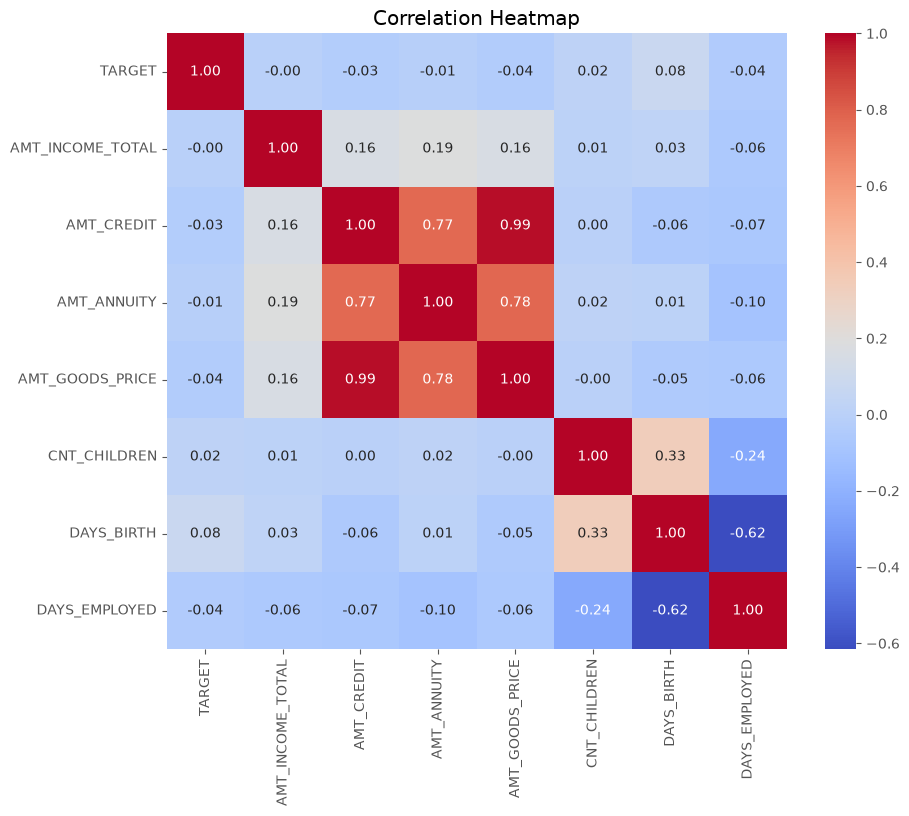

In [49]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insight

The heatmap highlights relationships among financial variables.

Strong positive or negative correlations can help identify variables that influence customer characteristics and loan repayment behavior.

## 24. Loan-to-Income Ratio

### Objective

Create a new feature representing the relationship between the requested loan amount and the customer's annual income.

This ratio is commonly used in credit risk assessment.

In [50]:
df["LOAN_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

df["LOAN_INCOME_RATIO"].head()

/var/folders/3w/b06x_mhx0qv718wn0ytkp7380000gn/T/ipykernel_12362/4259233063.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["LOAN_INCOME_RATIO"] = (


0    2.007889
1    4.790750
2    2.000000
3    2.316167
4    4.222222
Name: LOAN_INCOME_RATIO, dtype: float64

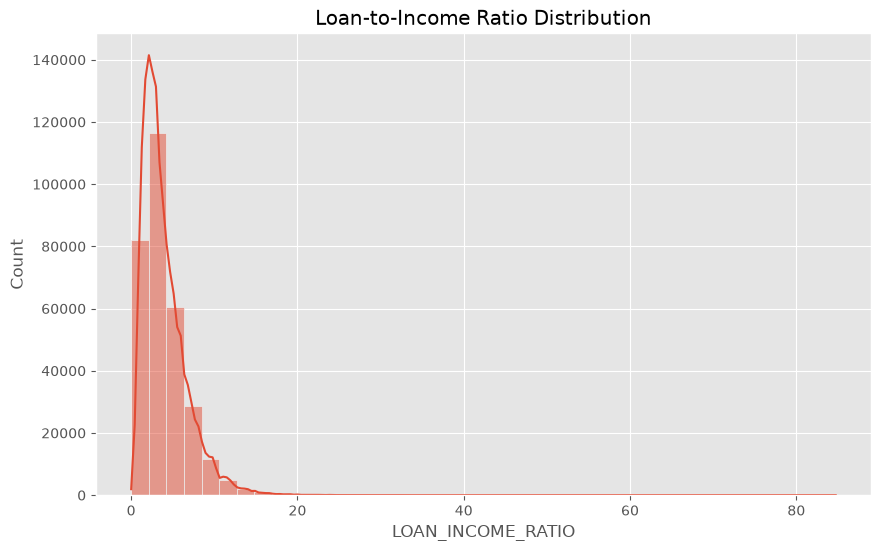

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["LOAN_INCOME_RATIO"],
    bins=40,
    kde=True
)

plt.title("Loan-to-Income Ratio Distribution")

plt.show()

### Business Insight

A higher loan-to-income ratio indicates that customers are requesting loans that represent a larger proportion of their income, which may increase financial risk.

## 25. Loan-to-Income Ratio by Loan Status

### Objective

Compare loan-to-income ratios between customers who repaid their loans and those who defaulted.

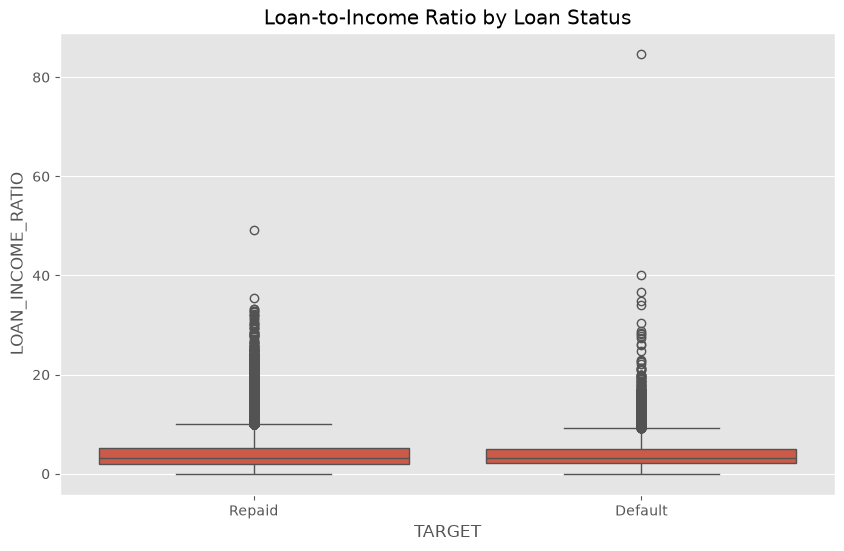

In [52]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="TARGET",
    y="LOAN_INCOME_RATIO"
)

plt.xticks([0,1],["Repaid","Default"])

plt.title("Loan-to-Income Ratio by Loan Status")

plt.show()

### Business Insight

Compare whether customers who defaulted generally have higher loan-to-income ratios than customers who repaid successfully.

## 26. Customer Age Groups

### Objective

Group customers into age categories to analyze repayment behavior by age segment.

In [53]:
df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[20,30,40,50,60,70],
    labels=[
        "20-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70"
    ]
)

df["AGE_GROUP"].value_counts()

/var/folders/3w/b06x_mhx0qv718wn0ytkp7380000gn/T/ipykernel_12362/3549516422.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_GROUP"] = pd.cut(


AGE_GROUP
31-40    82308
41-50    76541
51-60    68062
20-30    45021
61-70    35579
Name: count, dtype: int64

In [54]:
age_default = pd.crosstab(
    df["AGE_GROUP"],
    df["TARGET"],
    normalize="index"
) * 100

age_default

TARGET,0,1
AGE_GROUP,,
20-30,88.543124,11.456876
31-40,90.416484,9.583516
41-50,92.349198,7.650802
51-60,93.870295,6.129705
61-70,95.078558,4.921442


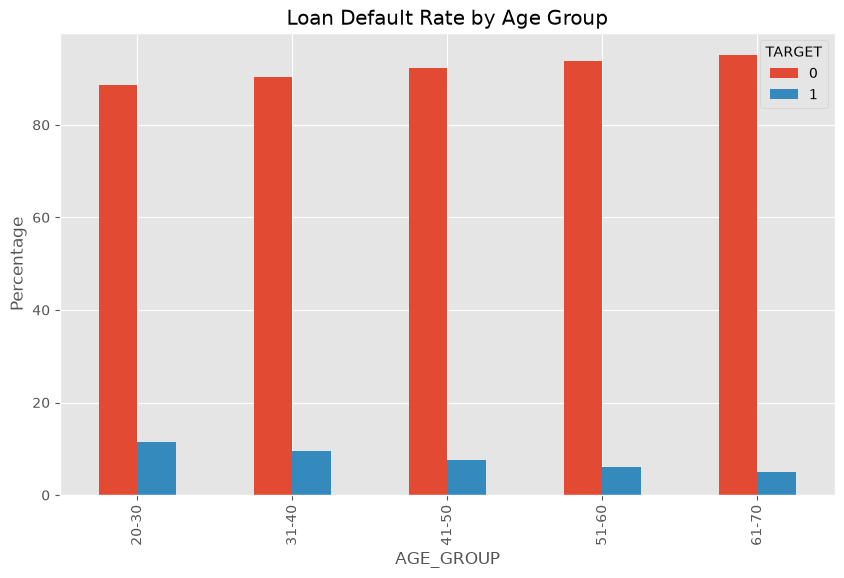

In [55]:
age_default.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Loan Default Rate by Age Group")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Age group analysis helps identify customer segments with relatively higher repayment risk.

These insights can support targeted risk assessment and customer management strategies.

## 27. Income Groups

### Objective

Segment customers into income categories for further financial analysis.

In [56]:
df["INCOME_GROUP"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["INCOME_GROUP"].value_counts()

/var/folders/3w/b06x_mhx0qv718wn0ytkp7380000gn/T/ipykernel_12362/3929504180.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["INCOME_GROUP"] = pd.qcut(


INCOME_GROUP
Low          100578
High          82213
Very High     71538
Medium        53182
Name: count, dtype: int64

In [57]:
income_group_default = pd.crosstab(
    df["INCOME_GROUP"],
    df["TARGET"],
    normalize="index"
) * 100

income_group_default

TARGET,0,1
INCOME_GROUP,,
Low,91.605520,8.394480
Medium,91.468918,8.531082
High,91.604734,8.395266
Very High,93.090386,6.909614


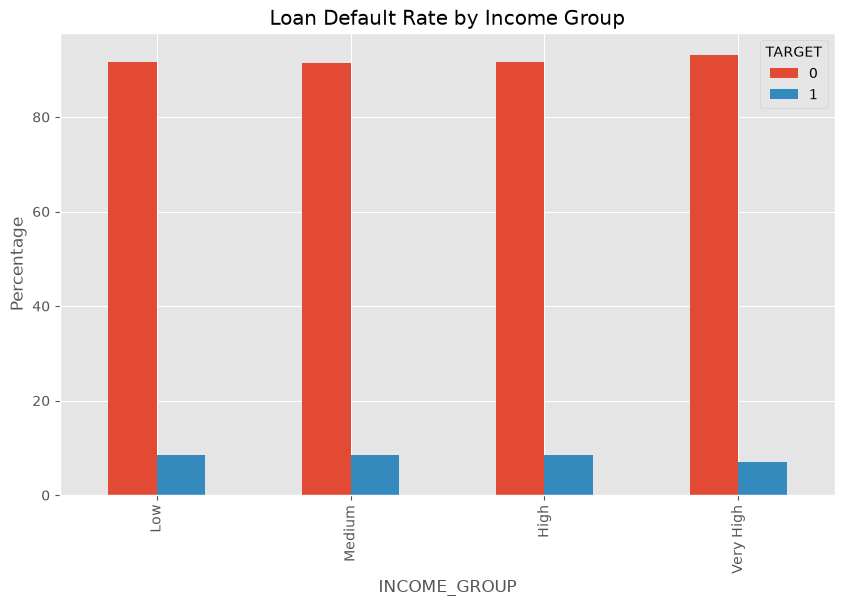

In [58]:
income_group_default.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Loan Default Rate by Income Group")

plt.ylabel("Percentage")

plt.show()

### Business Insight

Income segmentation provides insight into how repayment behavior varies across different income levels.

Banks can use this information to improve customer profiling and credit risk assessment.

# Phase 4: Customer Risk Segmentation

## Objective

The purpose of this phase is to identify high-risk customer groups by creating business-driven features and performing customer segmentation.

Banks use customer segmentation to prioritize loan approvals, monitor high-risk applicants, and improve lending strategies.

## 28. Employment Duration Analysis

### Objective

Analyze the employment duration of customers to understand workforce stability.

In [59]:
df["YEARS_EMPLOYED"] = abs(df["DAYS_EMPLOYED"]) / 365

df["YEARS_EMPLOYED"].head()

/var/folders/3w/b06x_mhx0qv718wn0ytkp7380000gn/T/ipykernel_12362/1388421028.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["YEARS_EMPLOYED"] = abs(df["DAYS_EMPLOYED"]) / 365


0    1.745205
1    3.254795
2    0.616438
3    8.326027
4    8.323288
Name: YEARS_EMPLOYED, dtype: float64

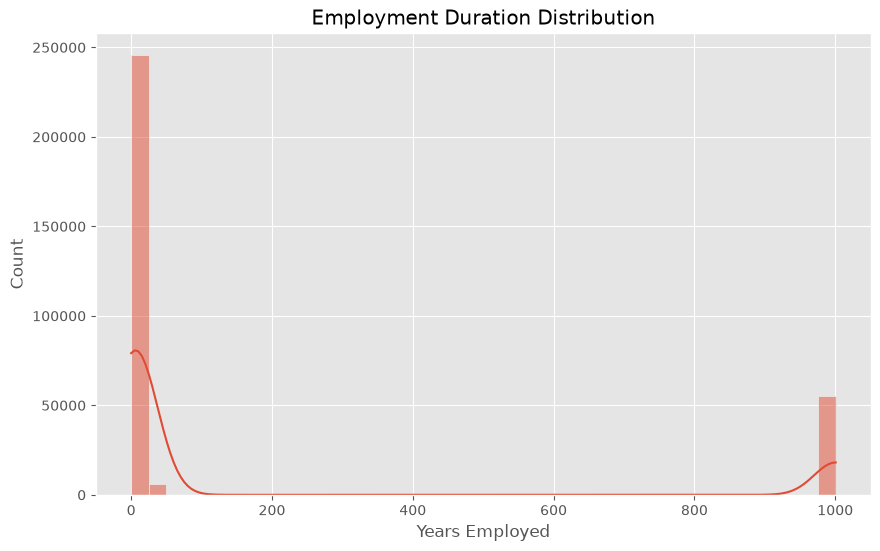

In [60]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["YEARS_EMPLOYED"],
    bins=40,
    kde=True
)

plt.title("Employment Duration Distribution")
plt.xlabel("Years Employed")

plt.show()


### Business Insight

Employment duration provides an indication of job stability.

Customers with longer employment histories generally demonstrate greater financial stability, although this should be evaluated together with other financial indicators.

## 29. Employment Duration by Loan Status

### Objective

Compare employment duration between customers who repaid their loans and those who defaulted.

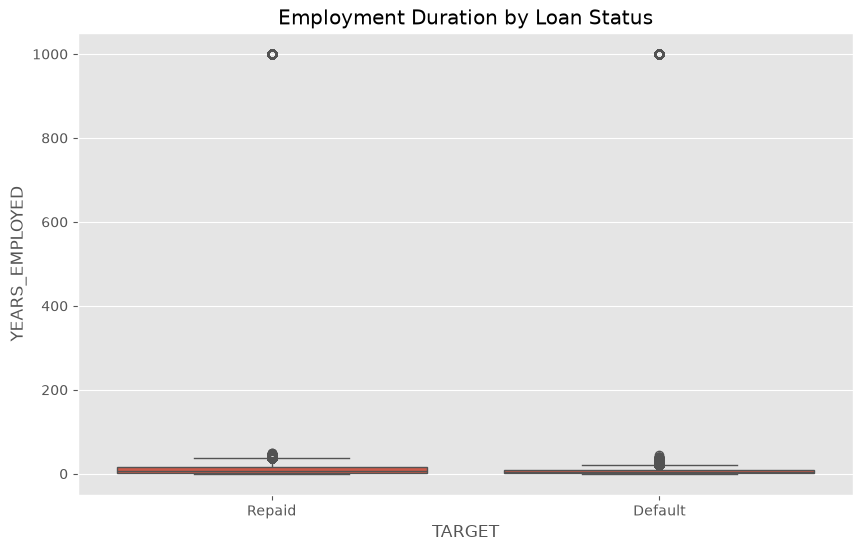

In [61]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="TARGET",
    y="YEARS_EMPLOYED"
)

plt.xticks([0,1],["Repaid","Default"])

plt.title("Employment Duration by Loan Status")

plt.show()

### Business Insight

Compare employment duration across repayment groups.

Longer employment duration may be associated with improved repayment stability.

## 30. Customer Risk Categories

### Objective

Create customer segments based on the Loan-to-Income Ratio.

These categories help identify applicants with different levels of financial exposure.

In [62]:
df["RISK_LEVEL"] = pd.cut(
    df["LOAN_INCOME_RATIO"],
    bins=[0,1,2,4,100],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["RISK_LEVEL"].value_counts()

/var/folders/3w/b06x_mhx0qv718wn0ytkp7380000gn/T/ipykernel_12362/1582812955.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["RISK_LEVEL"] = pd.cut(


RISK_LEVEL
Very High    117612
High         113561
Medium        60164
Low           16174
Name: count, dtype: int64

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="RISK_LEVEL",
    order=["Low","Medium","High","Very High"]
)

plt.title("Customer Risk Categories")

plt.show()

### Business Insight

Customers with higher loan-to-income ratios are classified into higher risk categories.

This segmentation supports credit risk monitoring and lending decisions.

## 31. Risk Category vs Loan Default

### Objective

Compare default rates across customer risk categories.

In [64]:
risk_default = pd.crosstab(
    df["RISK_LEVEL"],
    df["TARGET"],
    normalize="index"
) * 100

risk_default

TARGET,0,1
RISK_LEVEL,,
Low,93.563744,6.436256
Medium,92.304368,7.695632
High,91.129877,8.870123
Very High,92.278849,7.721151


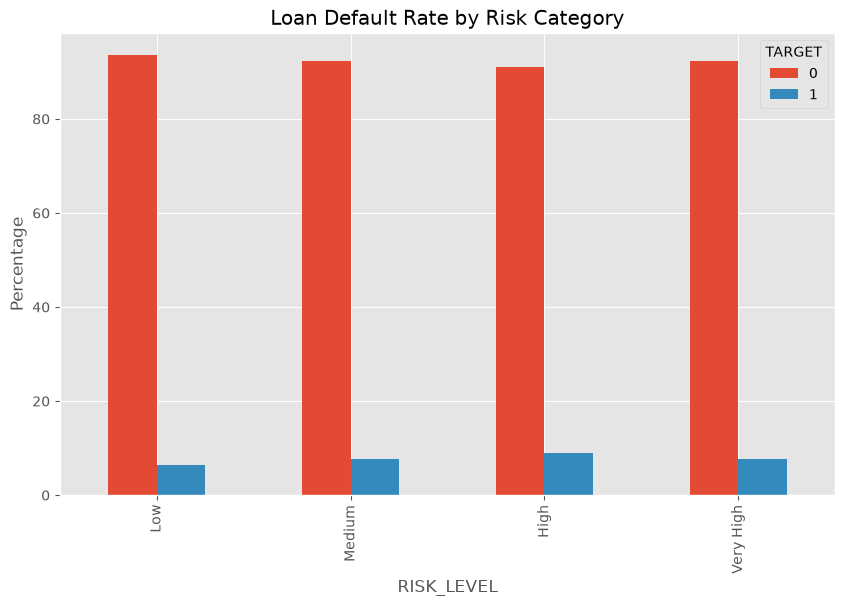

In [65]:
risk_default.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Loan Default Rate by Risk Category")
plt.ylabel("Percentage")

plt.show()

### Business Insight

Higher-risk customer groups should be monitored more closely during loan approval and repayment.

This analysis helps identify whether the risk categories align with actual default behavior.

## 32. Income vs Credit Amount

### Objective

Examine the relationship between customer income and requested credit amount.

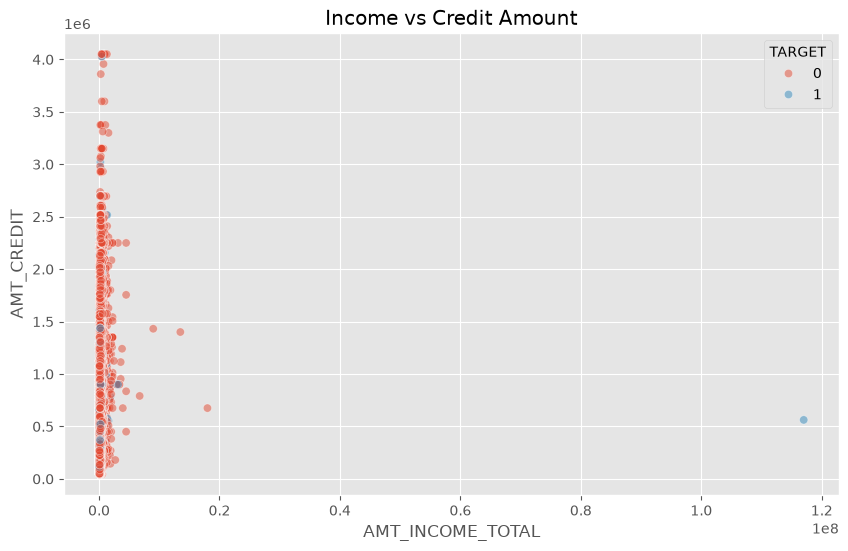

In [66]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    y="AMT_CREDIT",
    hue="TARGET",
    alpha=0.5
)

plt.title("Income vs Credit Amount")

plt.show()

### Business Insight

The scatter plot illustrates the relationship between annual income and requested credit amount.

Applicants requesting large loans despite relatively low income may require additional review during the lending process.

# Phase 4 Summary

## Key Findings

- Employment duration provides insight into customer financial stability.
- Loan-to-income ratio is an important financial indicator.
- Customer segmentation helps identify higher-risk applicants.
- Income and requested credit amount should be evaluated together during loan approval.
- Multiple variables should be considered jointly rather than relying on a single metric when assessing credit risk.